# Cell assembly and steady-state polarization curve

`marapendi` is a Python library for physics-based modelling of proton-exchange
membrane fuel cells (PEMFCs). Its core design follows three principles:

* **Component dataclasses.** Every physical component — membrane (`PFSA`), catalyst
  layers (`PtCCatalystLayer`), gas diffusion layers (`GasDiffusionLayer`), and flow
  channels (`FlowChannel`) — is a Python `dataclass` carrying its geometric and
  material parameters. Components are assembled into a `FuelCell` object.
* **Stateless models.** `ExplicitSteadyStateModel` (and its implicit and transient
  variants) are decoupled from the cell. They receive a `FuelCell` and
  `CellConditions` at solve time and return a `CellState` with all computed
  quantities — voltage, MEA temperature, water content, saturations, and transport
  resistances.
* **Vectorised evaluation.** Passing an array of current densities to
  `CellConditions` evaluates all operating points simultaneously in one call.

This notebook is the minimal entry point to the API:

1. Assemble a `FuelCell` from its component dataclasses.
2. Define `CellConditions` (current density, temperature, pressures, relative
   humidities, stoichiometries).
3. Compute a steady-state polarization curve with `ExplicitSteadyStateModel`
   in a single vectorised call.

The cell parameters below are the 18-parameter estimation result for MEA62
from `08_parameter_estimation.ipynb`. See that notebook for the full
parameter-estimation and cross-validation workflow.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import marapendi as mrpd

## 1 — Cell parameters

Parameters are split into two groups, mirroring the estimation workflow in
`08_parameter_estimation.ipynb`:

* **Fixed parameters** — geometric or structural values held at their nominal
  values (GDL porosity, contact angles, ionomer stoichiometry coefficients, etc.).
  These are not varied during parameter estimation.
* **Estimated parameters** — the 18 parameters identified from the MEA62
  polarisation-curve dataset (n = 18, test condition 2 as left-out fold).

All values are in SI base units (m, kg, s, K, mol, A). `marapendi` dataclasses
accept them directly — no unit conversion is needed by the caller.

## 2 — Cell assembly

`marapendi` models the MEA as a tree of nested dataclasses:

- `FuelCell` — top-level container, owns the membrane and both sides.
- `FuelCellSide` (`.ca`, `.an`) — one electrode side; holds a `PtCCatalystLayer`,
  `GasDiffusionLayer`, and `FlowChannel`.
- `PFSA` membrane — composes a `PFSAIonomer` (ionomer transport properties:
  conductivity, water diffusivity, absorption coefficient) with membrane-level
  geometry (`dry_thickness`).

Gas transport in GDLs and flow channels is injected via `transport_resistance_model`
and `two_phase_transport_model` fields, keeping porous-layer dataclasses independent
of the chosen transport model.

`ExplicitSteadyStateModel` is stateless and instantiated separately; it receives
the assembled `FuelCell` and `CellConditions` objects at solve time.

In [21]:

nafion = mrpd.PFSAIonomer(
    equivalent_weight=1100.,
    dry_density=1900.,
    conductivity_exp=1.5,
    conductivity_activation_energy=20e6,
    conductivity_correction=1.,
    reference_water_diffusivity=2e-10,
    reference_water_absorption_coefficient=1e-06,
    water_diffusivity_activation_energy=20e6,
    water_absorption_activation_energy=20e6,
)

membrane = mrpd.PFSA(
    dry_thickness=12e-6,
    ionomer=nafion,
)

orr_kinetics = mrpd.ElectrochemicalReaction(
    reference_exchange_current_density=1e-3,
    reaction_order=0.8,
    activation_energy=67e6,
    reference_activity=1.01325e5,
    reference_temperature=353.15,
    number_of_electrons=1,
    charge_transfer_coeff=1,
)

liq_model = mrpd.DarcyTransportModel(J_function_exponent=0.4)

gdl = {
    side: mrpd.GasDiffusionLayer(
        thickness=180e-6,
        contact_angle=120.,
        effective_gas_diffusion_ratio=0.25,
        absolute_permeability=1e-12,
        porosity=0.6,
        thermal_conductivity=1.5,
        two_phase_transport_model=liq_model,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(water_saturation_exponent=2.0),
    ) for side in ['ca', 'an']
}

ch = {
    side: mrpd.FlowChannel(
        height=1e-3, width=1e-3, n_parallel=1, length=21 * 50e-3,
        reactant='o2' if side == 'ca' else 'h2',
        transport_resistance_model=mrpd.ChannelGasResistanceModel(sherwood=3, B_ch=1),
    ) for side in ['an', 'ca']
}

ca_cl = mrpd.PtCCatalystLayer(
    ecsa=60e3, platinum_loading=0.3e-2, ionomer=nafion,
    catalyst_platinum_weight_percent=0.4,
    ionomer_to_carbon_ratio=1.4,
    ionomer_k1=8.5, ionomer_k2=5.4, ionomer_k3=5.4,
    pore_diameter=40e-9, omega_PtO=0,
    carbon_agglomerate_radius=40e-9,
    thickness=0.3e-2 * 2.8e-6 / 0.1e-2,
    absolute_permeability=1e-13, contact_angle=97.,
    thermal_conductivity=0.22, reaction=orr_kinetics,
    two_phase_transport_model=liq_model,
)

an_cl = mrpd.PtCCatalystLayer(
    ecsa=60e3, platinum_loading=1e-3,
    catalyst_platinum_weight_percent=0.4,
    ionomer_to_carbon_ratio=1.4, ionomer=nafion,
    pore_diameter=40e-9, carbon_agglomerate_radius=25e-9,
    thickness=2.8e-6, absolute_permeability=1e-13, contact_angle=97.,
    thermal_conductivity=0.22, two_phase_transport_model=liq_model,
)

cell = mrpd.FuelCell(
    electrical_resistance=1e-06,
    area=25e-4,
    ca=mrpd.FuelCellSide(cl=ca_cl, gdl=gdl['ca'], has_gdl=True, has_mpl=False, ch=ch['ca'],
                         thermal_contact_resistance=4.4e-4),
    an=mrpd.FuelCellSide(cl=an_cl, gdl=gdl['an'], has_gdl=True, has_mpl=False, ch=ch['an'],
                         thermal_contact_resistance=4.4e-4),
    membrane=membrane,
)

model = mrpd.ExplicitSteadyStateModel()

## 3 — Operating conditions and steady-state sweep

`current_density` may be an array: `ExplicitSteadyStateModel.solve` evaluates every
operating point in one vectorised call.  The cell is passed explicitly to
`set_initial_conditions` and `solve`, keeping the model stateless.

In [22]:
current_density = np.linspace(0.02, 2.0, 40) * 1e4  # A/m^2

conditions = mrpd.CellConditions(
    current_density=current_density,
    cell_temperature=80 + 273.15,
    ca=mrpd.SideConditions(inlet_temperature=353.15, outlet_pressure=1.5e5, inlet_relative_humidity=0.5,
                           dry_o2_mole_fraction=0.21, stoichiometry=2.0),
    an=mrpd.SideConditions(inlet_temperature=353.15, outlet_pressure=1.5e5, inlet_relative_humidity=0.5,
                           dry_h2_mole_fraction=1.0, stoichiometry=1.5),
)

state = model.set_initial_conditions(cell, conditions)
state = model.solve(cell, conditions, state)

## 4 — Polarization and power-density curves

`state.cell_voltage` is the array of cell voltages (one per current density point)
returned by `ExplicitSteadyStateModel.solve`. The `CellState` object exposes the full
set of internal variables: `state.membrane` (water content, proton resistance),
`state.ca` / `state.an` (electrode water fluxes, saturation, species partial pressures),
and `state.ca.cl` / `state.an.cl` (catalyst-layer saturation, ionomer water content,
proton resistance).

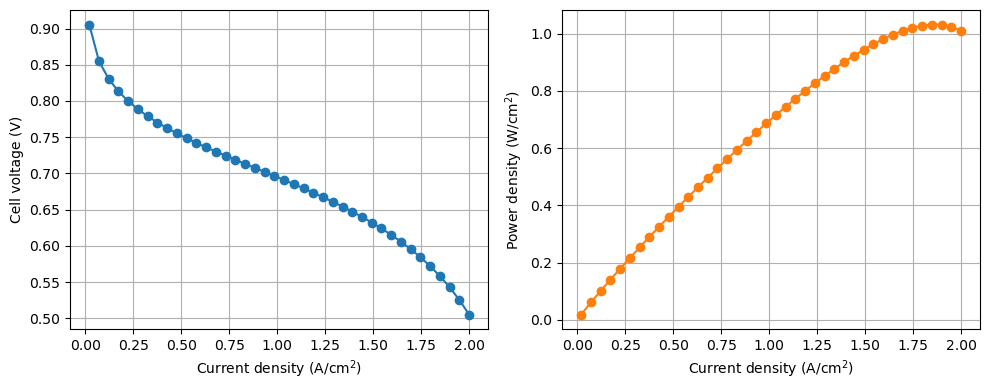

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(current_density * 1e-4, state.cell_voltage, 'o-')
ax1.set_xlabel('Current density (A/cm$^2$)')
ax1.set_ylabel('Cell voltage (V)')
ax1.grid()

power_density = current_density * 1e-4 * state.cell_voltage
ax2.plot(current_density * 1e-4, power_density, 'o-', color='C1')
ax2.set_xlabel('Current density (A/cm$^2$)')
ax2.set_ylabel('Power density (W/cm$^2$)')
ax2.grid()

fig.tight_layout()
plt.show()